Homework6- Mobina Haghshenas- 402125057

# Data Preparation

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

#for data preprocessing
from sklearn.decomposition import PCA

#for modeling
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

#filter warnings
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [8]:
df = pd.read_csv(r"bank-additional-full (1).csv")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Handle Missing Values

In [9]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

As it seems, there is no missing values.

##  Encode Categorical Features

In [21]:
from sklearn.preprocessing import LabelEncoder

categorical_features = df.select_dtypes(include=['object']).columns
print("Categorical features:", len(categorical_features))
categorical_df = df[categorical_features]

# Assuming 'encoded_feature' is the new column where you want to store the encoded values
for column in categorical_df.columns:
    encoder = LabelEncoder()
    df[column+'_encoded'] = encoder.fit_transform(categorical_df[column])

df.drop(categorical_features, axis=1, inplace=True)

Categorical features: 11


# Exploratory Data Analysis (EDA)

## Descriptive Statistics

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Visualizations

In [23]:
df.y_encoded.value_counts()

y_encoded
0    36548
1     4640
Name: count, dtype: int64

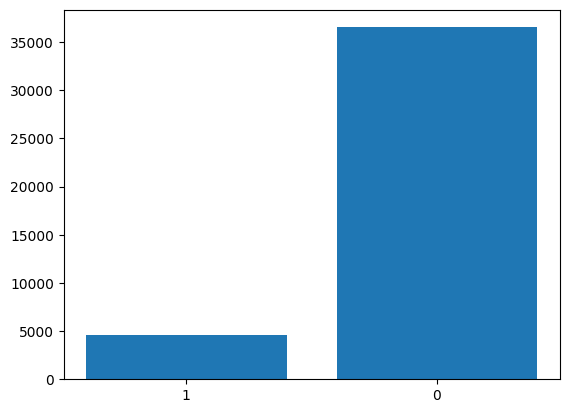

In [24]:
plt.bar(['1','0'],[4640,36548])
plt.show()

We have 12% fraud cases in the dataset which are anomalies.

## Explore the distribution of data for each feature

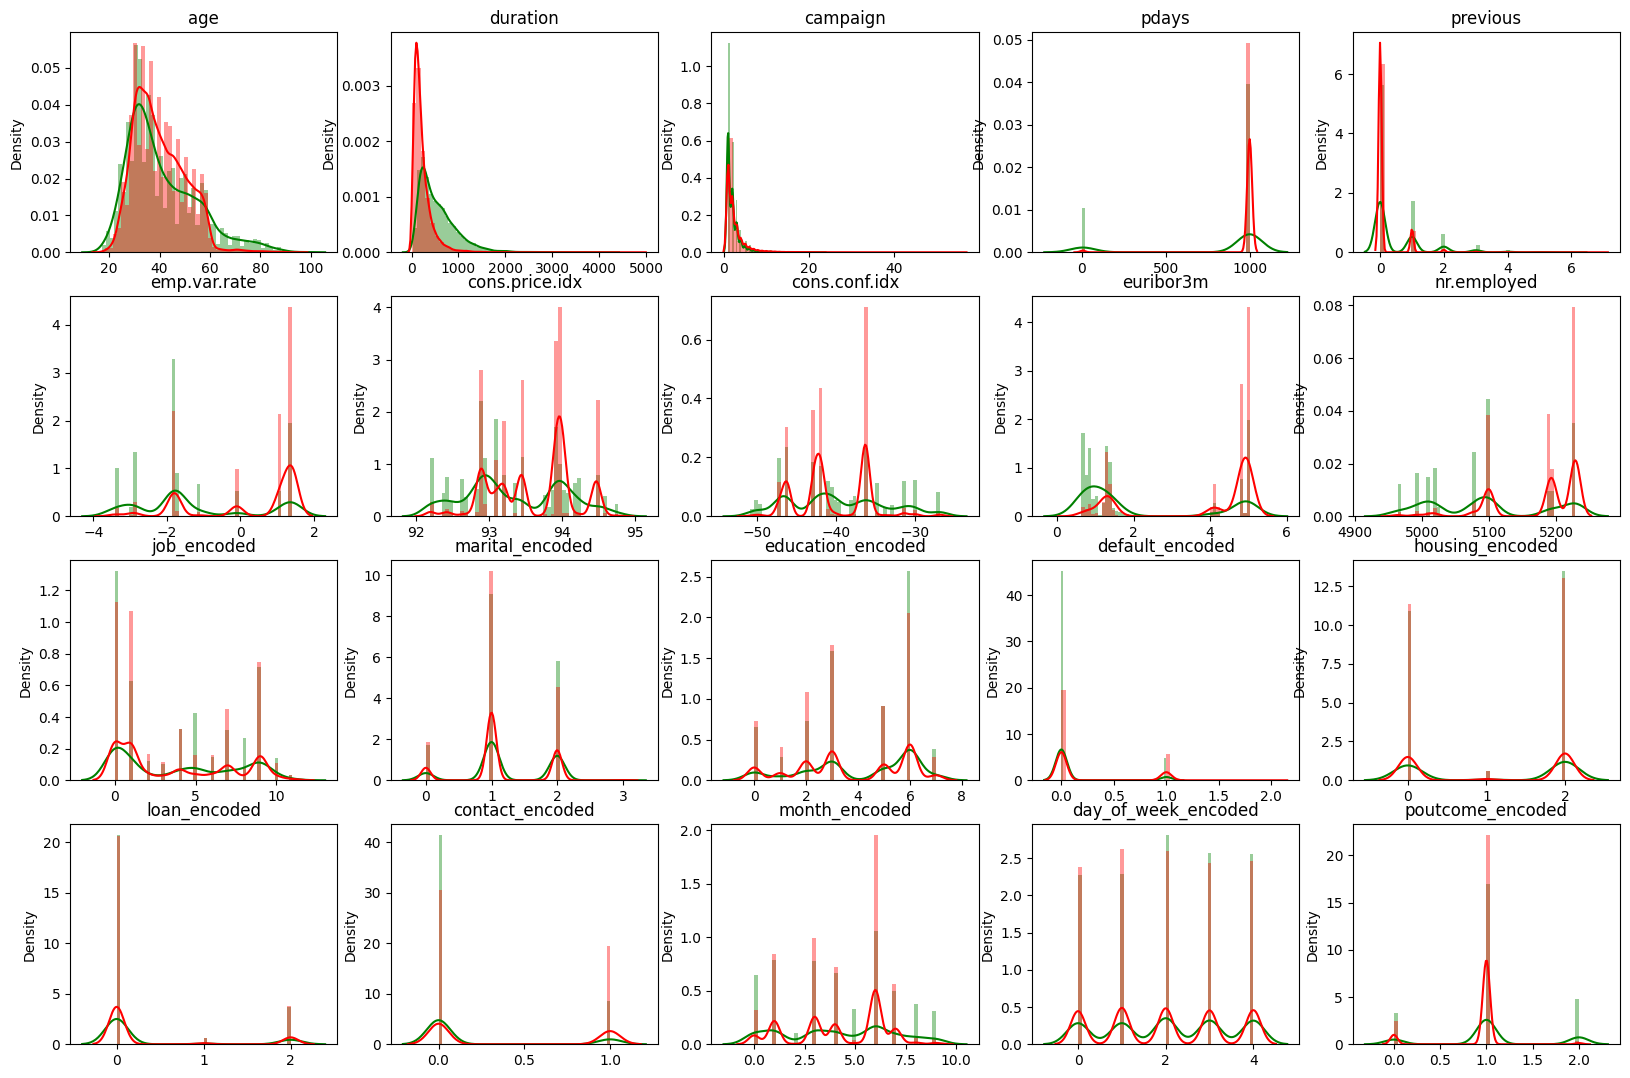

In [29]:
columns = df.drop('y_encoded', axis=1).columns
grid = gridspec.GridSpec(6, 5)

plt.figure(figsize=(20,10*2))

for n, col in enumerate(df[columns]):
    ax = plt.subplot(grid[n])
    sns.distplot(df[df.y_encoded==1][col], bins = 50, color='g')
    sns.distplot(df[df.y_encoded==0][col], bins = 50, color='r')
    ax.set_ylabel('Density')
    ax.set_title(str(col))
    ax.set_xlabel('')

plt.show()

## Z-test for Significant Variables

In [30]:
def ztest(feature):

    mean = normal[feature].mean()
    std = fraud[feature].std()
    zScore = (fraud[feature].mean() - mean) / (std/np.sqrt(sample_size))

    return zScore

In [33]:
columns= df.drop('y_encoded', axis=1).columns
normal= df[df.y_encoded==0]
fraud= df[df.y_encoded==1]
sample_size=len(fraud)
significant_features=[]
critical_value=2.58

for i in columns:

    z_vavlue=ztest(i)

    if( abs(z_vavlue) >= critical_value):
        print(i," is statistically significant") #Reject Null hypothesis. i.e. H0
        significant_features.append(i)

age  is statistically significant
duration  is statistically significant
campaign  is statistically significant
pdays  is statistically significant
previous  is statistically significant
emp.var.rate  is statistically significant
cons.price.idx  is statistically significant
cons.conf.idx  is statistically significant
euribor3m  is statistically significant
nr.employed  is statistically significant
job_encoded  is statistically significant
marital_encoded  is statistically significant
education_encoded  is statistically significant
default_encoded  is statistically significant
contact_encoded  is statistically significant
day_of_week_encoded  is statistically significant
poutcome_encoded  is statistically significant


As we have already seen from distribution plots that distribution of normal and fraud data of housing_encoded, loan_encoded, month_encoded features are almost same, now, its proven through hypothesis testing. We will eliminate these features from our dataset as they don't contribute at all.

## Split data into Inliers and Outliers


In [34]:
significant_features.append('y_encoded')
df= df[significant_features]

inliers = df[df.y_encoded==0]
ins = inliers.drop(['y_encoded'], axis=1)

outliers = df[df.y_encoded==1]
outs = outliers.drop(['y_encoded'], axis=1)

ins.shape, outs.shape

((36548, 17), (4640, 17))

# Model Selection

## Scenario 1: Inlier **Data**

In [35]:
def normal_accuracy(values):

    tp=list(values).count(1)
    total=values.shape[0]
    accuracy=np.round(tp/total,4)

    return accuracy

def fraud_accuracy(values):

    tn=list(values).count(-1)
    total=values.shape[0]
    accuracy=np.round(tn/total,4)

    return accuracy

### Isolation Forest

In [36]:
state= 42

ISF = IsolationForest(random_state=state)
ISF.fit(ins)

normal_isf = ISF.predict(ins)
fraud_isf = ISF.predict(outs)

in_accuracy_isf=normal_accuracy(normal_isf)
out_accuracy_isf=fraud_accuracy(fraud_isf)
print("Accuracy in Detecting Normal Cases:", in_accuracy_isf)
print("Accuracy in Detecting Fraud Cases:", out_accuracy_isf)

Accuracy in Detecting Normal Cases: 0.7774
Accuracy in Detecting Fraud Cases: 0.6731


### Local Outlier Factor

In [37]:
LOF = LocalOutlierFactor(n_neighbors = 20, contamination=0.2, novelty = True)
LOF.fit(ins)

normal_lof = LOF.predict(ins)
fraud_lof = LOF.predict(outs)

in_accuracy_lof=normal_accuracy(normal_lof)
out_accuracy_lof=fraud_accuracy(fraud_lof)
print("Accuracy in Detecting Normal Cases:", in_accuracy_lof)
print("Accuracy in Detecting Fraud Cases:", out_accuracy_lof)

Accuracy in Detecting Normal Cases: 0.8188
Accuracy in Detecting Fraud Cases: 0.3334


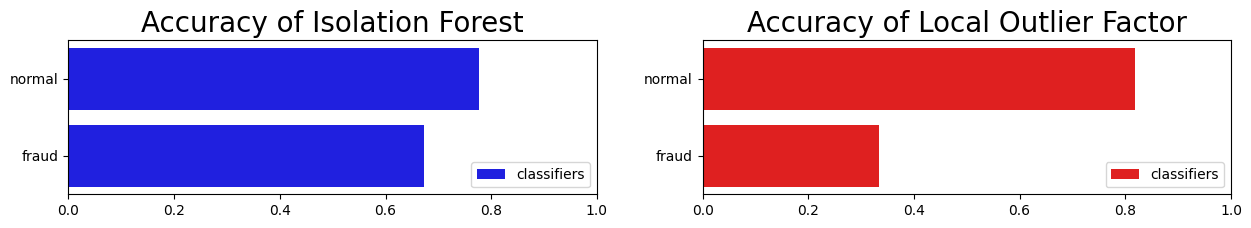

In [38]:
fig, (ax1,ax2)= plt.subplots(1,2, figsize=[15,2])

ax1.set_title("Accuracy of Isolation Forest",fontsize=20)
sns.barplot(x=[in_accuracy_isf,out_accuracy_isf],
            y=['normal', 'fraud'],
            label="classifiers",
            color="b",
            ax=ax1)
ax1.set(xlim=(0,1))

ax2.set_title("Accuracy of Local Outlier Factor",fontsize=20)
sns.barplot(x=[in_accuracy_lof,out_accuracy_lof],
            y=['normal', 'fraud'],
            label="classifiers",
            color="r",
            ax=ax2)
ax2.set(xlim=(0,1))
plt.show()

## Scenario 2: Subsample with Outliers


### Generate subsample

In [49]:
# Obtain outlier scores from the Isolation Forest model
isf_scores = ISF.decision_function(outs)

# Set a threshold for outlier scores
isf_threshold = np.percentile(isf_scores, 95)  # Example: 95th percentile

# Filter outliers based on the threshold
selected_outliers_isf = outs[isf_scores > isf_threshold]

# Randomly select the same number of outliers as inliers
num_inliers = len(ins)
selected_outliers_isf = selected_outliers_isf.sample(n=num_inliers, replace=True, random_state=42)

# Combine inliers and randomly selected outliers to create subsample
subsample = pd.concat([ins, selected_outliers_isf])



### Tuned model

In [50]:
#ISF
state= 42

ISF = IsolationForest(random_state=state)
ISF.fit(subsample)

normal_isf = ISF.predict(ins)
fraud_isf = ISF.predict(outs)

in_accuracy_isf=normal_accuracy(normal_isf)
out_accuracy_isf=fraud_accuracy(fraud_isf)
print("Accuracy in Detecting Normal Cases:", in_accuracy_isf)
print("Accuracy in Detecting Fraud Cases:", out_accuracy_isf)

Accuracy in Detecting Normal Cases: 0.5572
Accuracy in Detecting Fraud Cases: 0.7091


In [51]:
LOF = LocalOutlierFactor(n_neighbors = 20, contamination=0.2, novelty = True)
LOF.fit(subsample)

normal_lof = LOF.predict(ins)
fraud_lof = LOF.predict(outs)

in_accuracy_lof=normal_accuracy(normal_lof)
out_accuracy_lof=fraud_accuracy(fraud_lof)
print("Accuracy in Detecting Normal Cases:", in_accuracy_lof)
print("Accuracy in Detecting Fraud Cases:", out_accuracy_lof)

Accuracy in Detecting Normal Cases: 0.625
Accuracy in Detecting Fraud Cases: 0.5334


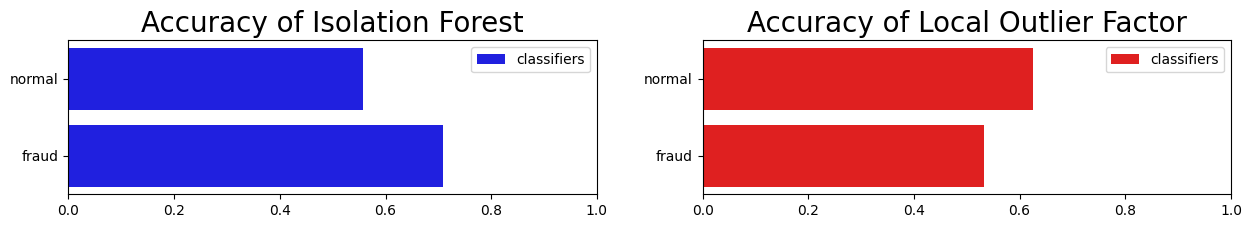

In [52]:
fig, (ax1,ax2)= plt.subplots(1,2, figsize=[15,2])

ax1.set_title("Accuracy of Isolation Forest",fontsize=20)
sns.barplot(x=[in_accuracy_isf,out_accuracy_isf],
            y=['normal', 'fraud'],
            label="classifiers",
            color="b",
            ax=ax1)
ax1.set(xlim=(0,1))

ax2.set_title("Accuracy of Local Outlier Factor",fontsize=20)
sns.barplot(x=[in_accuracy_lof,out_accuracy_lof],
            y=['normal', 'fraud'],
            label="classifiers",
            color="r",
            ax=ax2)
ax2.set(xlim=(0,1))
plt.show()

Compare the accuracy of IForest and LOF across both scenarios. Discuss the following aspects:

• How well do the models perform on inlier data? We can check this one based on plot in Scenario 1.

• Does the presence of outliers in the subsample affect model accuracy? Yes!

• Which model seems more robust to outliers?  IST

• Are there any limitations to consider based on the chosen metrics or data characteristics?  We can consider the balance between inliers and outliers, the distribution of data, and any biases in the data.